# Synthetic Data Generation Using RAGAS - RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow!



- 🤝 BREAKOUT ROOM #1
  1. Use RAGAS to Generate Synthetic Data

- 🤝 BREAKOUT ROOM #2
  1. Load them into a LangSmith Dataset
  2. Evaluate our RAG chain against the synthetic test data
  3. Make changes to our pipeline
  4. Evaluate the modified pipeline

SDG is a critical piece of the puzzle, especially for early iteration! Without it, it would not be nearly as easy to get high quality early signal for our application's performance.

Let's dive in!

# 🤝 BREAKOUT ROOM #1

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

> NOTE: DO NOT RUN THESE CELLS IF YOU ARE RUNNING THIS NOTEBOOK LOCALLY

In [1]:
#!pip install -qU ragas==0.2.10

In [2]:
#!pip install -qU langchain-community==0.3.14 langchain-openai==0.2.14 unstructured==0.16.12 langgraph==0.2.61 langchain-qdrant==0.2.0

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [3]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/ahmed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ahmed/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [5]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [6]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - and download our webpages which we'll be using for our data today.

These webpages are from [Simon Willison's](https://simonwillison.net/) yearly "AI learnings".

- [2023 Blog](https://simonwillison.net/2023/Dec/31/ai-in-2023/)
- [2024 Blog](https://simonwillison.net/2024/Dec/31/llms-in-2024/)

Let's start by collecting our data into a useful pile!

In [7]:
!mkdir data

mkdir: data: File exists


In [8]:
!curl https://simonwillison.net/2023/Dec/31/ai-in-2023/ -o data/2023_llms.html

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 31524    0 31524    0     0  44893      0 --:--:-- --:--:-- --:--:-- 44905


In [9]:
!curl https://simonwillison.net/2024/Dec/31/llms-in-2024/ -o data/2024_llms.html

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 70549    0 70549    0     0   100k      0 --:--:-- --:--:-- --:--:--  100k


Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [10]:
from langchain_community.document_loaders import DirectoryLoader

path = "data/"
loader = DirectoryLoader(path, glob="*.html")
docs = loader.load()

libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.


### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [11]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [12]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [13]:
from ragas.testset.graph import Node, NodeType

for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 2, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [14]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/12 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 10, relationships: 28)

We can save and load our knowledge graphs as follows.

In [15]:
kg.save("ai_across_years_kg.json")
ai_across_years_kg = KnowledgeGraph.load("ai_across_years_kg.json")
ai_across_years_kg

KnowledgeGraph(nodes: 10, relationships: 28)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [16]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=ai_across_years_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [17]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

#### ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

SingleHopSpecificQuerySynthesizer:
Creates simple, specific questions that can be answered directly from one small piece of information. Example: "When was GPT-4 released?"

MultiHopAbstractQuerySynthesizer:
Creates more complex and abstract questions that require combining multiple pieces of information and logical reasoning. Example: "How did LLM architectures evolve between 2020 and 2024?"

MultiHopSpecificQuerySynthesizer:
Creates complex but very specific questions that involve retrieving multiple concrete facts from the documents. Example: "List the major LLM launches of 2023 and their creators."


Finally, we can use our `TestSetGenerator` to generate our testset!

In [18]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,Google what is it,[The ethics of this space remain diabolically ...,The context mentions Google as one of the orga...,single_hop_specifc_query_synthesizer
1,Considering the advancements in AI as discusse...,[Simon Willison’s Weblog Subscribe Stuff we fi...,"According to Simon Willison’s weblog, 2023 was...",single_hop_specifc_query_synthesizer
2,What is DALL-E 3?,[the document includes some of the clearest ex...,The provided context does not include a specif...,single_hop_specifc_query_synthesizer
3,What is the significance of Willow Creek in th...,[The environmental impact got better The envir...,Willow Creek is mentioned as the setting for a...,single_hop_specifc_query_synthesizer
4,How does OpenAI's recent API development relat...,"[also accepts audio input, and the Google Gemi...",OpenAI started with a WebSocket API that was q...,single_hop_specifc_query_synthesizer
5,How do the capabilities of LLMs reflect their ...,[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,The context indicates that Large Language Mode...,multi_hop_abstract_query_synthesizer
6,How do the themes of prompt-driven application...,"[<1-hop>\n\nalso accepts audio input, and the ...",The context illustrates that prompt-driven app...,multi_hop_abstract_query_synthesizer
7,How do the ethical and legal issues surroundin...,[<1-hop>\n\nas a substantial component of pret...,The context highlights that while large langua...,multi_hop_abstract_query_synthesizer
8,How do Google's efforts in LLMs relate to thei...,[<1-hop>\n\nthe document includes some of the ...,The context shows that Google is one of the or...,multi_hop_specific_query_synthesizer
9,How do recent developments in ChatGPT's multim...,[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,Recent developments in ChatGPT's multimodal ca...,multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [19]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/12 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/20 [00:00<?, ?it/s]

unable to apply transformation: 'StringIO' object has no attribute 'output'


Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [20]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,Google is like what in AI?,[The ethics of this space remain diabolically ...,The context mentions that in the past 24-36 mo...,single_hop_specifc_query_synthesizer
1,What does Microsoft have to do with LLMs and A...,"[and software engineer, LLMs are infuriating. ...",The context mentions Microsoft in relation to ...,single_hop_specifc_query_synthesizer
2,Whaat are the main advancments and chalenges w...,[Simon Willison’s Weblog Subscribe Stuff we fi...,Simon Willison’s weblog notes that 2023 was a ...,single_hop_specifc_query_synthesizer
3,What is the significance of Llama in the conte...,[the document includes some of the clearest ex...,Llama is mentioned among the top topics relate...,single_hop_specifc_query_synthesizer
4,"Hw is LLMs and AI tech in 2024, and how do the...",[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,"In 2024, Large Language Models (LLMs) have see...",multi_hop_abstract_query_synthesizer
5,"How do AI technologies and tools like GPT, Lla...",[<1-hop>\n\nthe document includes some of the ...,The context highlights that AI technologies an...,multi_hop_abstract_query_synthesizer
6,How does the impact of AI on society and emplo...,[<1-hop>\n\nThe ethics of this space remain di...,The context highlights that Large Language Mod...,multi_hop_abstract_query_synthesizer
7,how does generative ai relate to the ai tools ...,[<1-hop>\n\nthe document includes some of the ...,the context explains that generative ai is a m...,multi_hop_abstract_query_synthesizer
8,how LLMs are really smart but also really dumb...,"[<1-hop>\n\nand software engineer, LLMs are in...","Based on the context, LLMs are considered both...",multi_hop_specific_query_synthesizer
9,so in 2024 what are the main things we learned...,[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,"In 2024, we learned that LLMs have advanced si...",multi_hop_specific_query_synthesizer


We'll need to provide our LangSmith API key, and set tracing to "true".

# 🤝 BREAKOUT ROOM #2

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [26]:
from langsmith import Client

client = Client()

dataset_name = "State of AI Across the Years-a!"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="State of AI Across the Years!"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [27]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [28]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [29]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [30]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [31]:
from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="State of AI"
)

In [32]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [33]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

For our LLM, we will be using TogetherAI's endpoints as well!

We're going to be using Meta Llama 3.1 70B Instruct Turbo - a powerful model which should get us powerful results!

In [34]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [35]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [36]:
rag_chain.invoke({"question" : "What are Agents?"})

'Based on the provided context, "agents" is an extremely vague and frustrating term with no single, clear, and widely understood meaning. Generally, it seems to refer to AI systems that can go away and act on your behalf, such as the travel agent model or large language models (LLMs) given access to tools they can run repeatedly to solve problems. However, there are dozens of possible definitions, and people using the term often do not clarify which meaning they intend. Despite much discussion and excitement, few if any fully realized AI agents are running in production yet, partly due to challenges like gullibility of LLMs and the difficulty of achieving autonomy without AGI. Overall, agents remain a concept that is perpetually "coming soon" but not yet clearly or practically realized.'

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [37]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [38]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

dope_or_nope_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "dopeness": "Is this submission dope, lit, or cool?",
        },
        "llm" : eval_llm
    }
)

#### 🏗️ Activity #2:

Highlight what each evaluator is evaluating.

- `qa_evaluator`:
- `labeled_helpfulness_evaluator`:
- `dope_or_nope_evaluator`:

## LangSmith Evaluation

In [39]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dope_or_nope_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'advanced-price-48' at:
https://smith.langchain.com/o/67e6e5ff-33e9-45c0-86bc-ff2c9b1b19ed/datasets/7a3fa64b-e5fa-413a-9b3d-d3d5183aea3f/compare?selectedSessions=c519e583-7b80-43a4-9473-4bcd3245b200




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,how microsoft and microsoft are involved in LL...,"Based on the provided context, Microsoft is in...",None,The context mentions that Microsoft Research h...,1,1,0,4.795733,1042bd7e-83af-46d0-9c0e-bcfef77b0ca8,bb6627aa-9c66-4739-b2c7-0380e51b6368
1,How do the complexities and challenges of unde...,"Based on the provided context, the complexitie...",None,The context highlights that ChatGPT and other ...,1,1,0,5.148083,90dec3c6-2065-4e08-b00d-32d3e3ffd36d,93206385-1a8a-493e-adcb-8de5b9295412
2,so in 2024 what are the main things we learned...,"Based on the provided context, here are the ma...",None,"In 2024, we learned that LLMs have advanced si...",1,1,0,11.783352,06292f74-be89-443c-9992-a4db1312aff1,a0e79230-84ca-4a2a-bc63-8ca029de939c
3,how LLMs are really smart but also really dumb...,"Based on the context provided, here’s what it ...",None,"Based on the context, LLMs are considered both...",1,1,0,5.738017,c6e1dcc1-3fc0-4bd9-8759-440898381ce6,b678c01b-a0f2-401e-9eaa-9b320b6ee586
4,how does generative ai relate to the ai tools ...,Based on the provided context:\n\nGenerative A...,None,the context explains that generative ai is a m...,1,1,0,8.590253,4cc8003c-b5c0-49aa-af65-9110032f78a3,93b1cdbd-ce53-4e4f-a4c9-a65525849f54
5,How does the impact of AI on society and emplo...,"Based on the context provided, the impact of A...",None,The context highlights that Large Language Mod...,1,1,0,3.243468,9c2c8464-4ce3-4c85-84d2-6cf062b3d02d,8de96925-a46c-475f-a412-af20322f7b5c
6,"How do AI technologies and tools like GPT, Lla...",The context indicates that AI technologies and...,None,The context highlights that AI technologies an...,1,1,0,3.050168,7554e370-8e28-4b06-b48d-e08ee8445347,cd0a605d-4ffa-4fc3-8624-92b386ebb6fc
7,"Hw is LLMs and AI tech in 2024, and how do the...","Based on the provided context, in 2024, Large ...",None,"In 2024, Large Language Models (LLMs) have see...",1,1,0,5.334208,929011a4-591c-4931-a874-e118a1a7dc26,63a591ba-a431-4dec-9e39-d14506d48f33
8,What is the significance of Llama in the conte...,"Llama, particularly Meta’s Llama 2 and Llama 3...",None,Llama is mentioned among the top topics relate...,1,1,0,7.021650,29a0b866-561b-4354-8301-7fd0471e3b56,f0543a05-5685-4595-8e6e-6a412bdf9668
9,Whaat are the main advancments and chalenges w...,"Based on the provided context, the main advanc...",None,Simon Willison’s weblog notes that 2023 was a ...,1,1,0,6.088519,ec9234b3-241c-4597-82c8-0aef1d658ede,7eec8f05-fd5f-445f-ade8-4f3e5375d869


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [40]:
DOPE_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

You must answer the questions in a dope way, be cool!

Context: {context}
Question: {question}
"""

dope_rag_prompt = ChatPromptTemplate.from_template(DOPE_RAG_PROMPT)

In [41]:
rag_documents = docs

In [42]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

#### ❓Question #2:

Why would modifying our chunk size modify the performance of our application?

Changing the chunk size affects how much information is available for answering a question.

Small chunks might miss important context, leading to incomplete or "I don't know" answers.

Larger chunks provide more context, helping the model find better answers, but if too large, they can add irrelevant information (noise).
A well-balanced chunk size improves retrieval quality and helps the model give more complete and accurate answers.

In [43]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

#### ❓Question #3:

Why would modifying our embedding model modify the performance of our application?

Embedding models convert text into vectors that are used to find relevant information.

A better embedding model (like text-embedding-3-large) captures the meaning of text more accurately.

This leads to better matches when retrieving documents, meaning the model finds the most relevant information faster and more reliably.
Better retrieval leads to better performance in answering questions.

In [44]:
vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="AI Across Years (Augmented)"
)

In [45]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [46]:
dope_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dope_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [47]:
dope_rag_chain.invoke({"question" : "what are Agents?"})

"Alright, listen up! Agents are kinda like this buzzword floating around in AI circles, but here’s the kicker — they don’t really have a solid, universally agreed-upon meaning yet. Some folks think of agents as AI systems that go act on your behalf, like a sleek travel agent booking your trips or running errands. Others see them as language models hooking up with tools, running loops to solve problems step by step.\n\nBut here’s the twist: they’re mostly still “coming soon” vibes. They struggle hard with gullibility — AI believing anything without fact-checking — which means these agents can't yet reliably make decisions for you. So, yeah, they’re hyped up but not quite cooking in the real world yet. In short, agents are AI systems that act autonomously, but the crown jewel of them? Still on the horizon, blocked by challenges like trustworthiness and truth-separating skills. Cool? Cool."

Finally, we can evaluate the new chain on the same test set!

In [48]:
evaluate(
    dope_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dope_or_nope_evaluator
    ],
    metadata={"revision_id": "dope_chain"},
)

View the evaluation results for experiment: 'reflecting-coal-32' at:
https://smith.langchain.com/o/67e6e5ff-33e9-45c0-86bc-ff2c9b1b19ed/datasets/7a3fa64b-e5fa-413a-9b3d-d3d5183aea3f/compare?selectedSessions=89d1d02b-2ed1-4fc5-a990-e1e357946479




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,how microsoft and microsoft are involved in LL...,"Yo, here’s the lowdown on Microsoft in the LLM...",None,The context mentions that Microsoft Research h...,1,1,1,5.485591,1042bd7e-83af-46d0-9c0e-bcfef77b0ca8,7881a61e-60d6-4ca5-8be9-91447f472591
1,How do the complexities and challenges of unde...,"Alright, here’s the skinny laid down fresh: Ch...",None,The context highlights that ChatGPT and other ...,1,1,1,4.263303,90dec3c6-2065-4e08-b00d-32d3e3ffd36d,6a634441-3b52-451d-95fa-ed5f6e666a19
2,so in 2024 what are the main things we learned...,"Alright, buckle up — here’s the lowdown on the...",None,"In 2024, we learned that LLMs have advanced si...",1,1,1,15.129969,06292f74-be89-443c-9992-a4db1312aff1,72e2183b-a3b5-45fb-9109-beecaead94f1
3,how LLMs are really smart but also really dumb...,"Alright, here’s the lowdown, straight from the...",None,"Based on the context, LLMs are considered both...",1,1,1,10.540346,c6e1dcc1-3fc0-4bd9-8759-440898381ce6,2ec28c7a-7312-453b-8e47-042ddc043241
4,how does generative ai relate to the ai tools ...,"Alright, let me break it down for you with the...",None,the context explains that generative ai is a m...,1,0,1,6.451354,4cc8003c-b5c0-49aa-af65-9110032f78a3,26cdf048-7313-4fd5-94e4-28c36c08e639
5,How does the impact of AI on society and emplo...,"Alright, here’s the lowdown—based on the conte...",None,The context highlights that Large Language Mod...,1,1,1,3.927377,9c2c8464-4ce3-4c85-84d2-6cf062b3d02d,e3adedd8-f337-4fb7-97fc-fa26532f162d
6,"How do AI technologies and tools like GPT, Lla...","Yo, here’s the scoop straight from the block—A...",None,The context highlights that AI technologies an...,1,0,1,3.729790,7554e370-8e28-4b06-b48d-e08ee8445347,92fccd41-cb08-41bc-b506-bf1d18f58781
7,"Hw is LLMs and AI tech in 2024, and how do the...","Yo, 2024 was straight-up lit for LLMs and AI t...",None,"In 2024, Large Language Models (LLMs) have see...",1,1,1,5.290664,929011a4-591c-4931-a874-e118a1a7dc26,edd4a4e1-2fd9-4f79-94ec-ed7f36389c9f
8,What is the significance of Llama in the conte...,"Alright, here’s the lowdown on Llama—it’s basi...",None,Llama is mentioned among the top topics relate...,1,1,1,5.013852,29a0b866-561b-4354-8301-7fd0471e3b56,fcce4a6a-1456-4105-bc76-91a1f57c30f2
9,Whaat are the main advancments and chalenges w...,"Yo, here’s the lowdown on the big moves and bu...",None,Simon Willison’s weblog notes that 2023 was a ...,1,1,1,5.114771,ec9234b3-241c-4597-82c8-0aef1d658ede,7d38d25c-c36e-41ce-bc96-dba43ed523ed


#### 🏗️ Activity #3:

Provide a screenshot of the difference between the two chains, and explain why you believe certain metrics changed in certain ways.



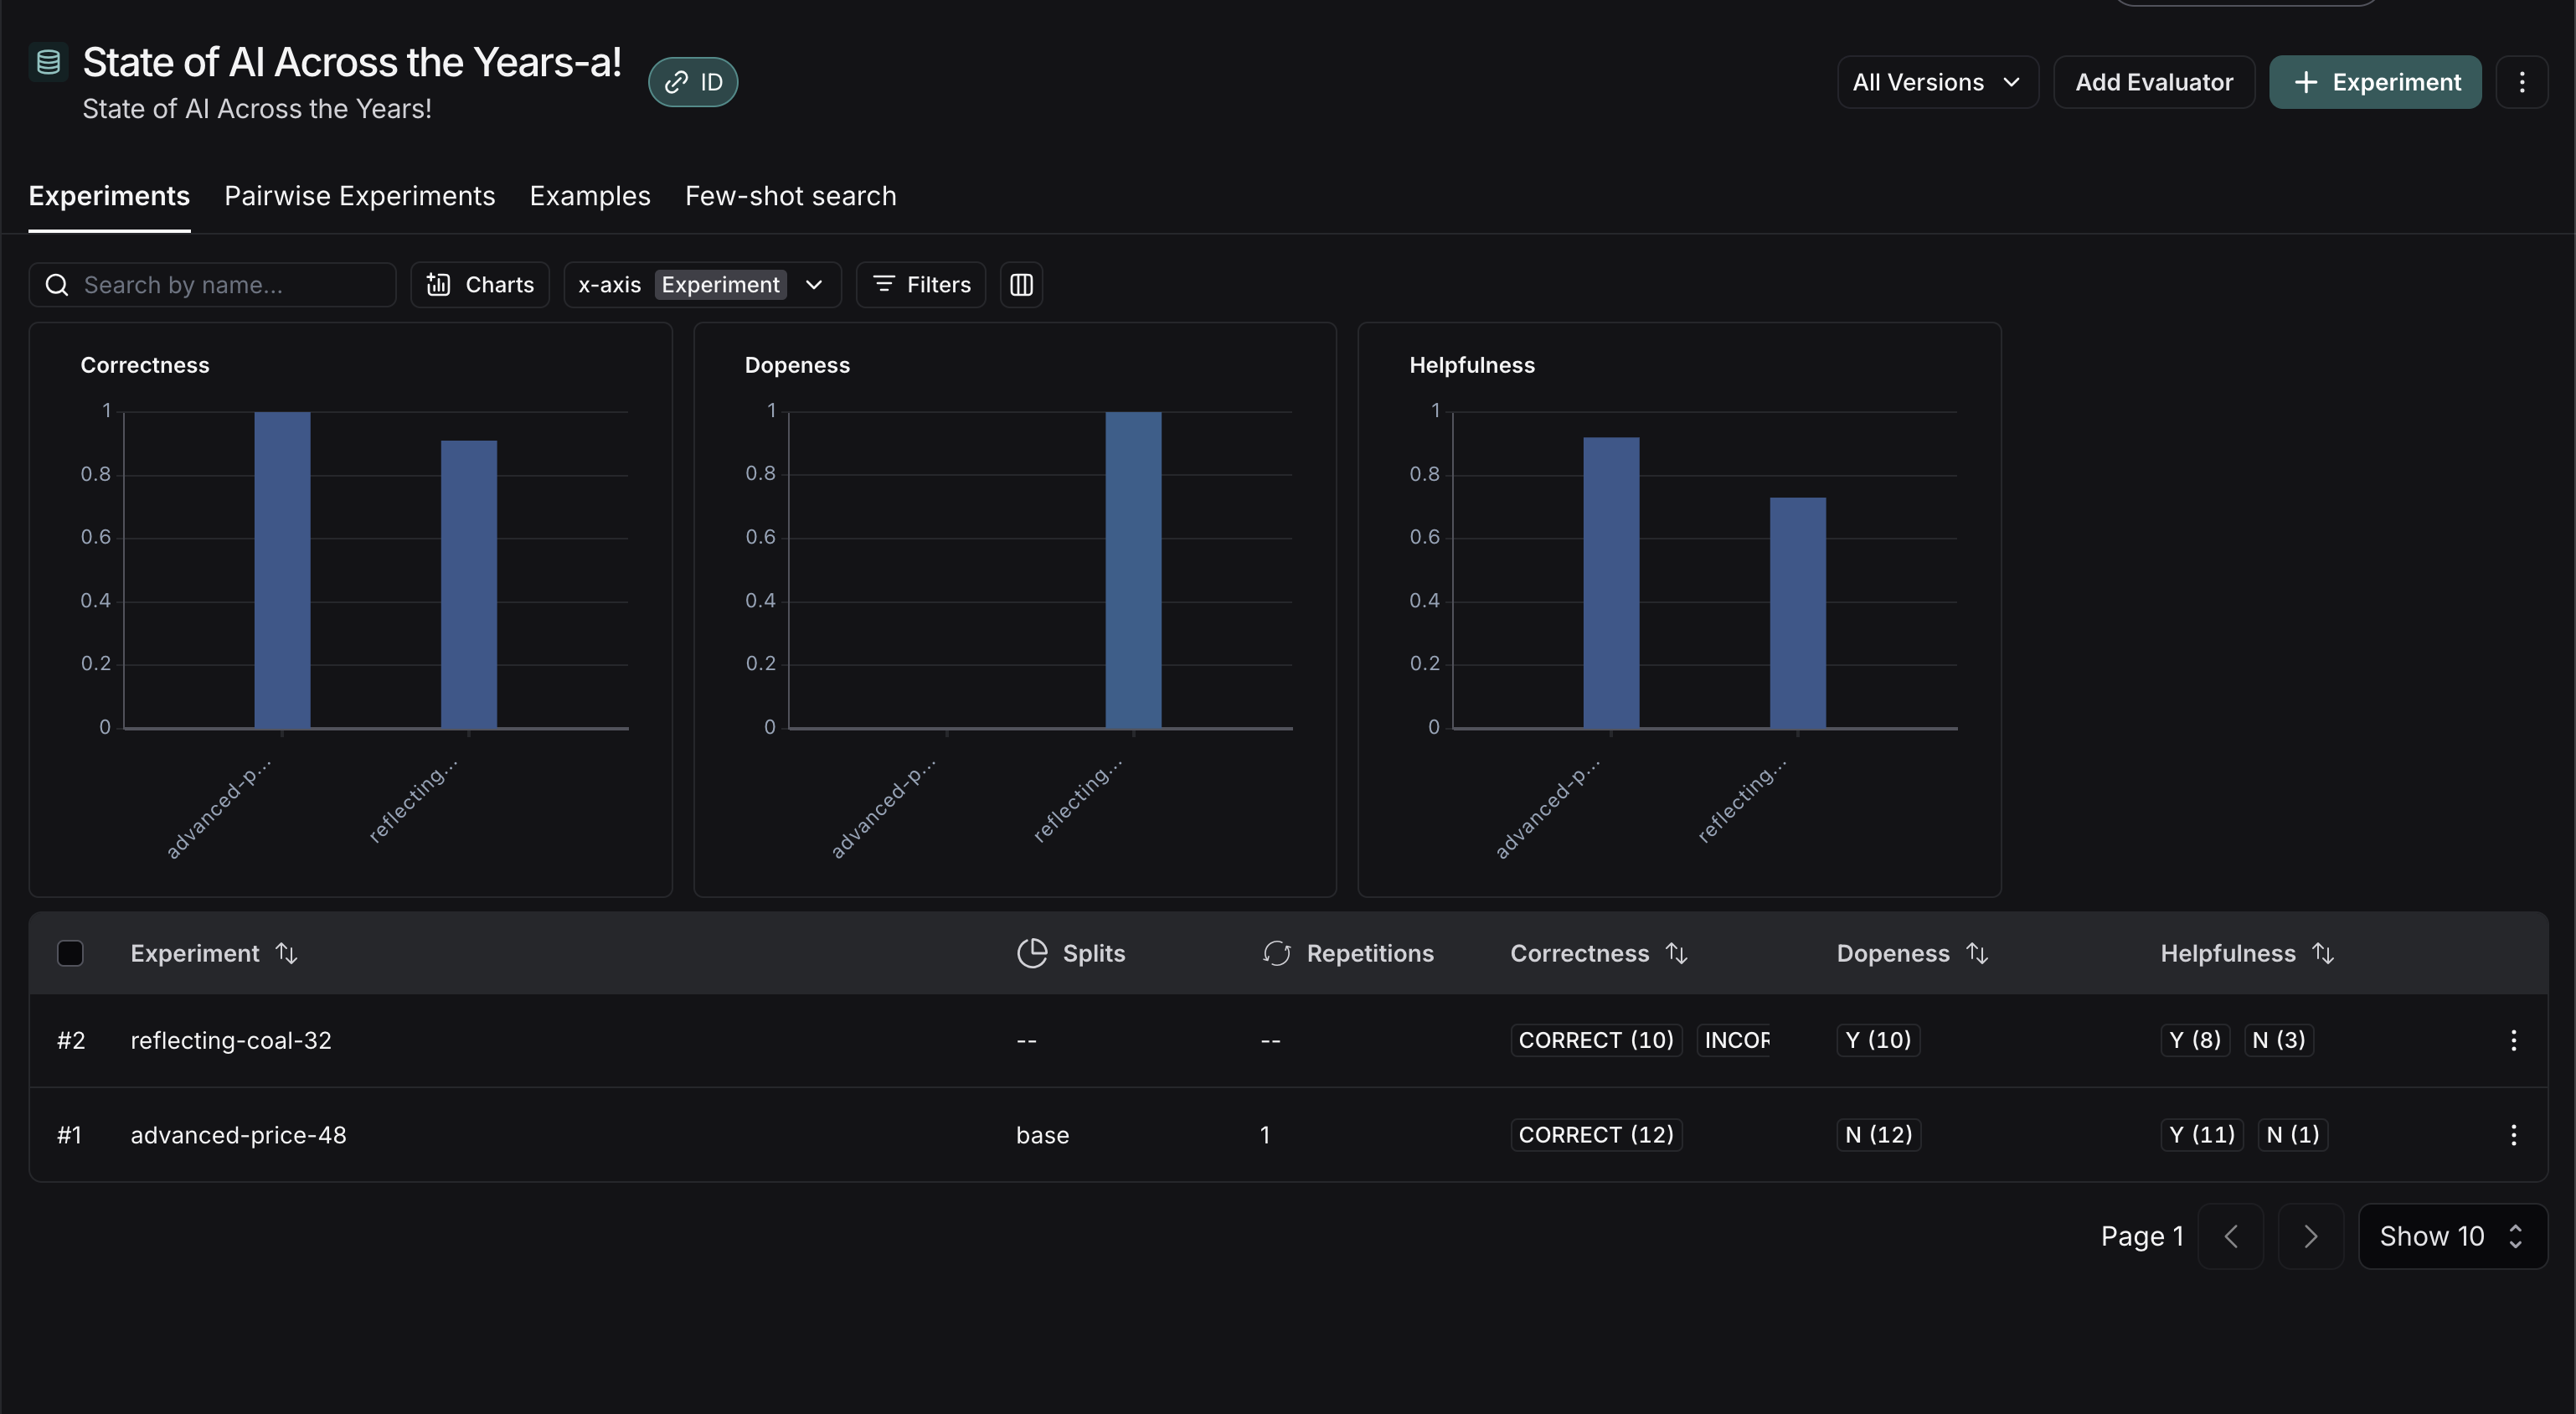

In [50]:
from IPython.display import Image

Image("LS.png")



The evaluation results clearly show the performance differences between the baseline RAG chain (advanced-price-48) and the improved, "dope" version (reflecting-coal-32).

Correctness: Both chains performed well in terms of accuracy. The default chain had 12 correct responses, while the dope chain had 10 correct responses — a slight drop, but still high-quality.

Helpfulness: The default chain had 11 helpful responses and 1 unhelpful, while the dope chain had 8 helpful and 3 unhelpful. This shows a small trade-off in helpfulness, potentially due to a shift in tone from adding the "dope" prompt.

Dopeness: This is where the biggest improvement is seen. The default chain had 0 "dope" responses (0/12), while the improved chain had 10/10 responses marked as dope. This confirms that the new prompt and generation style made the answers significantly more engaging and stylistically appealing.

By adjusting the prompt to be more engaging, increasing the chunk size, and switching to a stronger embedding model, the improved RAG chain delivers responses that are not only accurate but also much more appealing in tone and delivery. While there's a slight trade-off in helpfulness, the improvement in presentation makes the system more user-friendly and dynamic.